# Fake News Detection — NLP Project

Goal: build a classifier that distinguishes fake from real news articles,
using classic NLP techniques (TF-IDF, BoW, Word2Vec) and compare different
models (Logistic Regression, Naive Bayes, Random Forest).


## Setup & Data Loading


In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/skander/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/skander/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/skander/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /Users/skander/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/skander/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/skander/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## Exploratory Data Analysis (EDA)


In [2]:
import pandas as pd

# Load the datasets
data = pd.read_csv('dataset/data.csv')
validation = pd.read_csv('dataset/validation_data.csv')

# Basic checks
print("data.csv shape:", data.shape)
print("validation_data.csv shape:", validation.shape)
print()
print(data.head())

data.csv shape: (39942, 5)
validation_data.csv shape: (4956, 5)

   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29,

In [ ]:
#Features, label & Types 

print(data.columns.tolist())
print(data.dtypes)

['label', 'title', 'text', 'subject', 'date']
label       int64
title      object
text       object
subject    object
date       object
dtype: object


In [4]:
#Wie viele Fake- (0) vs. Real-News (1) haben wir in data.csv

# Count how many samples per class
print(data['label'].value_counts())

# As percentages
print(data['label'].value_counts(normalize=True) * 100)

label
1    19999
0    19943
Name: count, dtype: int64
label
1    50.070102
0    49.929898
Name: proportion, dtype: float64


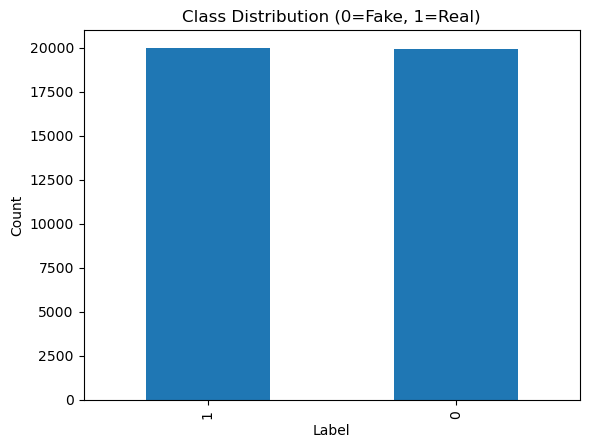

In [5]:

# Bonus — gleich visuell dazu, mit einem Balkendiagramm:

import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0=Fake, 1=Real)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [6]:
# Check for missing values
print(data.isnull().sum())

label      0
title      0
text       0
subject    0
date       0
dtype: int64


## Data Leakage Investigation


In [8]:

#Erstmal: wie viele Texte enthalten überhaupt "Reuters"
print("Anzahl Texte mit 'Reuters':", data['text'].str.contains('Reuters', case=False, na=False).sum())
print("Das sind:", round(data['text'].str.contains('Reuters', case=False, na=False).mean() * 100, 2), "% aller Texte")


Anzahl Texte mit 'Reuters': 20192
Das sind: 50.55 % aller Texte


In [10]:
#Schauen wir uns an, ob es noch andere häufige "Quellen-Muster" gibt — z.B. die ersten paar Wörter jedes Textes
# Look at the first 5 words of each text - often reveals a "dateline" pattern (LOCATION (SOURCE) -)
data['text_start'] = data['text'].str[:50]
print(data['text_start'].sample(20))  # random sample, not just the first 5 rows!

14987    MANILA (Reuters) - U.S. President Donald Trump...
29598    The investigation into the Las Vegas massacre ...
15708    DHAKA (Reuters) - The U.S. government will con...
822      YOKOTA AIR BASE, Japan (Reuters) - U.S. Presid...
30051    Legal expert and Constitutional law professor ...
7359     WASHINGTON (Reuters) - U.S. President Barack O...
6763     WASHINGTON (Reuters) - The White House said on...
28096    Donald Trump and the RNC have had a roller coa...
31089    Another great move by the Trump administration...
34554    Roger Simon of PJ Media asks Bernie Sanders  s...
13656    ABIDJAN (Reuters) - European leaders under pre...
3242     WASHINGTON (Reuters) - U.S. Attorney General J...
11881    MOMBASA, Kenya (Reuters) - Kenyan police raide...
29898    ST. LOUIS   Former St. Louis police Officer Ja...
29394    Send this kid back to China! The ungrateful at...
21325    After Friday s right-wing terror attack in Por...
6523      WASHINGTON (Reuters) - In a wide-ranging requ.

In [11]:
#Die subject-Spalte anschauen — vielleicht hängt DAS noch stärker mit label zusammen:
print(pd.crosstab(data['label'], data['subject']))

subject  Government News  News  left-news  politics  politicsNews  worldnews
label                                                                       
0                   1570  9050       2482      6841             0          0
1                      0     0          0         0         11272       8727


In [12]:
#Spalte 1: text — Reuters-Muster vs. label
#Was wir schon wissen: 50,55% aller Texte enthalten "Reuters" irgendwo.

# Create a column: does the text contain "Reuters"?
data['has_reuters'] = data['text'].str.contains('Reuters', case=False, na=False)

# Cross-tabulate: label (rows) vs. has_reuters (columns)
print(pd.crosstab(data['label'], data['has_reuters']))

# Same thing, but as percentage WITHIN each label (easier to read!)
print(pd.crosstab(data['label'], data['has_reuters'], normalize='index') * 100)

has_reuters  False  True 
label                    
0            19711    232
1               39  19960
has_reuters      False      True 
label                            
0            98.836685   1.163315
1             0.195010  99.804990


In [13]:
#Spalte 2: date — hängt das Datum auch mit dem Label zusammen?

# Check date column type and a sample
print(data['date'].dtype)
print(data['date'].sample(10))

# Convert text dates into real datetime format
data['date_parsed'] = pd.to_datetime(data['date'], errors='coerce')

# Earliest and latest date per label
print(data.groupby('label')['date_parsed'].agg(['min', 'max']))

# How many dates couldn't be converted?
print("Nicht lesbare Daten:", data['date_parsed'].isnull().sum())

object
28874        January 8, 2016
32100           Dec 19, 2016
24535     September 21, 2016
31657           Feb 15, 2017
19903    September 15, 2017 
16588      October 24, 2017 
37149           Aug 10, 2015
3969            May 1, 2017 
24727      September 7, 2016
19612    September 19, 2017 
Name: date, dtype: object
             min        max
label                      
0            NaT        NaT
1     2016-01-13 2017-12-31
Nicht lesbare Daten: 19943


In [14]:
#warum das Format bei Fake-Artikeln anders ist:
# Look at date formats separately for each label
print("Label 0 (Fake) - sample dates:")
print(data[data['label']==0]['date'].sample(10))
print()
print("Label 1 (Real) - sample dates:")
print(data[data['label']==1]['date'].sample(10))

Label 0 (Fake) - sample dates:
31748         Feb 3, 2017
24073    October 23, 2016
26462         May 9, 2016
28940     January 6, 2016
26057        June 2, 2016
35605         Jun 2, 2015
30914        May 11, 2017
33273        Aug 11, 2016
21756      April 17, 2017
33031        Sep 12, 2016
Name: date, dtype: object

Label 1 (Real) - sample dates:
805        November 6, 2017 
9825         April 22, 2016 
1441        October 3, 2017 
19885    September 16, 2017 
10708     February 23, 2016 
16887      October 20, 2017 
19716    September 18, 2017 
1245       October 13, 2017 
5669       February 3, 2017 
4375          April 7, 2017 
Name: date, dtype: object


In [15]:
# Diagnose: Warum genau scheitert das Parsing bei Fake-Artikeln?
# Show the RAW string representation — reveals hidden characters (extra spaces, special chars, etc.)
print("Label 0 (Fake) - raw repr:")
for d in data[data['label']==0]['date'].sample(5):
    print(repr(d))

print()
print("Label 1 (Real) - raw repr:")
for d in data[data['label']==1]['date'].sample(5):
    print(repr(d))

Label 0 (Fake) - raw repr:
'Apr 11, 2017'
'April 24, 2016'
'Sep 24, 2017'
'July 15, 2016'
'May 18, 2016'

Label 1 (Real) - raw repr:
'April 7, 2017 '
'May 18, 2017 '
'March 17, 2016 '
'May 26, 2016 '
'May 3, 2017 '


In [16]:
# Check title lengths and a sample per label
print(data.groupby('label')['title'].apply(lambda x: x.str.len().describe()))
print()
print("Label 0 (Fake) title samples:")
print(data[data['label']==0]['title'].sample(5))
print()
print("Label 1 (Real) title samples:")
print(data[data['label']==1]['title'].sample(5))

label       
0      count    19943.000000
       mean        94.964198
       std         26.228030
       min          8.000000
       25%         79.000000
       50%         90.000000
       75%        104.000000
       max        286.000000
1      count    19999.000000
       mean        64.627781
       std          9.164156
       min         26.000000
       25%         59.000000
       50%         64.000000
       75%         70.000000
       max        133.000000
Name: title, dtype: float64

Label 0 (Fake) title samples:
35930    PUERTO RICO: Local Cop Calls US Radio Station ...
24319     WATCH: The Daily Show Epically DESTROYS Fox N...
31826    LOL! Lifetime Politician Who Got 2% Support Fr...
21935     Republican’s Excuse For Cutting Food Stamps: ...
28730     Concerned Adult Literally Pays Young Black Ki...
Name: title, dtype: object

Label 1 (Real) title samples:
13353    Turkey seeks arrest of ex-CIA officer over sus...
1396     Senior U.S. House Republican expects action

## Preprocessing — Step 1: Remove Source Prefix


In [ ]:
# Schritt 1 : Reuters-Präfix entfernen 

#Teil A: Präfix schauen
print(data[data['label']==1]['text'].sample(5).tolist())


#Das Muster ist sehr konsistent:

    #Ein Städtename in GROSSBUCHSTABEN (HARARE, MOSCOW, LONDON, WASHINGTON, ZURICH)
    #Dann (Reuters)
    #Dann ein Bindestrich -
    #Dann ein Leerzeichen, und erst hier beginnt der eigentliche Artikel-Inhalt

#Teil B: Das Muster (Regex) bauen
import re

pattern = r'^[A-Z]+\s*\(Reuters\)\s*-\s*'

#Kurze Test 
test_text = "WASHINGTON (Reuters) - Key members of the U.S. Congress said..."
match = re.match(pattern, test_text)
print(match)

#Teil C: Jetzt das Muster wirklich anwenden (entfernen)
def remove_source_prefix(text):
    return re.sub(pattern, '', text)

data['text_clean'] = data['text'].apply(remove_source_prefix)

#Kurze Test 
# Compare before/after for a few Real articles
for i in range(3):
    print("VORHER: ", data[data['label']==1]['text'].iloc[i][:80])
    print("NACHHER:", data[data['label']==1]['text_clean'].iloc[i][:80])
    print()

['HAMBURG (Reuters) - French President Emmanuel Macron said on Saturday he had not given up on trying to get U.S. counterpart Donald Trump to change his mind about withdrawing the United States from the Paris climate change agreement. The final statement from the Group of 20 leaders meeting in Hamburg on Saturday exposed the divide that remains between the United States and other G20 members on the 2015 Paris accord aimed at combating climate change. But Macron also said he would host a summit on Dec. 12 to move the Paris deal forward. “On Dec. 12, two years after the Paris (climate) agreement, I will therefore convene a summit to take further action on climate, notably on the financial front,” Macron told reporters. He said that the summit would aim to mobilize private and public financing for the projects committed to under the Paris agreement. Asked if he was trying to persuade Trump to change his mind on the climate deal, Macro said: “I never despair to convince, because I think it

In [ ]:
## Check for other common news agency mentions
## (text_clean was created in the previous cell after removing the Reuters prefix)

for agency in ['Associated Press', ' AP ', 'AFP', 'Reuters']:
    count = data['text_clean'].str.contains(agency, case=False, na=False).sum()
    print(f"{agency}: {count} texts ({round(count/len(data)*100, 2)}%)")

Associated Press: 308 texts (0.77%)
 AP : 141 texts (0.35%)
AFP: 45 texts (0.11%)
Reuters: 8596 texts (21.52%)


In [25]:
# Does "Reuters" ever appear in titles too?
print(data['title'].str.contains('Reuters', case=False, na=False).sum())

139


In [26]:
#ob TITEL mit dem Label zusammenhängt, bevor wir entscheiden, ob wir was tun müssen:
print(pd.crosstab(data['label'], data['title'].str.contains('Reuters', case=False, na=False)))

title  False  True 
label              
0      19939      4
1      19864    135


## Train/Test Split


In [27]:
#Train/Test-Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text_clean'],
    data['label'],
    test_size=0.2,
    stratify=data['label'],
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31953
Test size: 7989


## Preprocessing Pipeline


In [28]:
#Preprocessing-Pipeline (Tokenization, Lowercasing, Stopwords, Lemmatization)

#Schritt 3a: Lowercasing + Tokenization
#Was wir hier machen: Jeden Text klein schreiben und in einzelne Wörter zerlegen — die Basis für alle weiteren Schritte.
#Wichtig: Wir wenden das getrennt auf X_train und X_test an (beide sind ja schon eigenständige Series nach dem Split).

from nltk.tokenize import word_tokenize

def tokenize_and_lower(text):
    tokens = word_tokenize(text.lower())
    return tokens

X_train_tokens = X_train.apply(tokenize_and_lower)
X_test_tokens = X_test.apply(tokenize_and_lower)

# Quick check
print(X_train_tokens.iloc[0][:15])

['crooked', 'lying', 'hillary']


In [29]:
print(len(X_train_tokens.iloc[0]))
print(X_train.iloc[0][:200])  # first 200 characters of the raw text

3
Crooked lying Hillary 


In [30]:
# 1. Check a few more random examples
for i in range(5):
    print(f"Doc {i}: {len(X_train_tokens.iloc[i])} tokens —", X_train.iloc[i][:100])

print()

# 2. Check the overall distribution of text lengths (word count) in the training set
text_lengths = X_train.str.split().str.len()
print(text_lengths.describe())

Doc 0: 3 tokens — Crooked lying Hillary 
Doc 1: 1857 tokens — Justice Scalia appeared to be in good health prior to his vacation at the Cibolo Creek Ranch in Texa
Doc 2: 458 tokens — A University of North Texas student is in critical condition after one of the NRA s  responsible gun
Doc 3: 0 tokens —  
Doc 4: 1162 tokens — Robert Mueller, the special counsel investigating possible ties between the Trump election campaign 

count    31953.000000
mean       390.429036
std        286.481226
min          0.000000
25%        205.000000
50%        362.000000
75%        505.000000
max       7033.000000
Name: text_clean, dtype: float64


In [31]:
# How many training documents have 0 words in text_clean?
empty_count = (X_train.str.split().str.len() == 0).sum()
print("Anzahl leerer Texte im Training:", empty_count)
print("Das sind:", round(empty_count / len(X_train) * 100, 3), "% der Trainingsdaten")

# Look at a few empty examples - check their titles!
empty_mask = X_train.str.split().str.len() == 0
empty_indices = X_train[empty_mask].index[:5]
print(data.loc[empty_indices, ['title', 'text', 'label']])

Anzahl leerer Texte im Training: 483
Das sind: 1.512 % der Trainingsdaten
                                                   title text  label
31791  #FireBenStein FOX NEWS’ BEN STEIN Calls Presid...           0
31989  WIKILEAKS HITS BACK At Lying Political Hack Ja...           0
31935  “LITTLE” MARCO RUBIO GRILLS Trump’s Secretary ...           0
38985  WATTERS’ WORLD: “Do you have Obamacare?”…”How ...           0
39894  WHAT WAS HE THINKING? DISHEVELED OBAMA YELLS F...           0


In [32]:
# Schritt 3: Drop leere Zeilen
train_mask = X_train.str.split().str.len() > 0
test_mask = X_test.str.split().str.len() > 0

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("New train size:", len(X_train))
print("New test size:", len(X_test))

# Schritt 4: Tokenization neu ausführen (weil X_train sich verändert hat)
X_train_tokens = X_train.apply(tokenize_and_lower)
X_test_tokens = X_test.apply(tokenize_and_lower)

New train size: 31470
New test size: 7862


In [ ]:
#weiter mit Punctuation + Stopwords entfernen
import string
import re
from nltk.corpus import stopwords

punct_pattern = re.compile('[%s]' % re.escape(string.punctuation))
stop_words = set(stopwords.words('english'))

def remove_punct_and_stopwords(tokens):
    cleaned = []
    for token in tokens:
        new_token = punct_pattern.sub('', token)
        if new_token != '' and new_token not in stop_words:
            cleaned.append(new_token)
    return cleaned

X_train_clean_tokens = X_train_tokens.apply(remove_punct_and_stopwords)
X_test_clean_tokens = X_test_tokens.apply(remove_punct_and_stopwords)

print(X_train_clean_tokens.iloc[1][:15])

['justice', 'scalia', 'appeared', 'good', 'health', 'prior', 'vacation', 'cibolo', 'creek', 'ranch', 'texas', 'owned', 'texas', 'millionaire', 'businessman']


In [34]:
#Lemmatization mit POS-Tagging
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0]
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]

X_train_lemmatized = X_train_clean_tokens.apply(lemmatize_tokens)
X_test_lemmatized = X_test_clean_tokens.apply(lemmatize_tokens)

print(X_train_lemmatized.iloc[1][:15])

['justice', 'scalia', 'appear', 'good', 'health', 'prior', 'vacation', 'cibolo', 'creek', 'ranch', 'texas', 'own', 'texas', 'millionaire', 'businessman']


In [35]:
#TF-IDF braucht Text-Strings, keine Token-Listen — wir müssen die Tokens wieder zu einem String zusammenfügen
X_train_final = X_train_lemmatized.apply(lambda tokens: ' '.join(tokens))
X_test_final = X_test_lemmatized.apply(lambda tokens: ' '.join(tokens))

print(X_train_final.iloc[1])

justice scalia appear good health prior vacation cibolo creek ranch texas own texas millionaire businessman democrat donor john poindexter many believe timing death coincidental reading detail provide source share thought u comment section belowit longstanding policy obama administration grant presidential award among president prize political donorsit poindexter reportedly among initially discover justice body coordinate local official justice scalia declare dead via phone conversation area medical examiner without actual medical examination bodymr poindexter also say primary point man ranch location federal authority notably slow arrive sceneif elizabeth price foley instapundit correct barack obama could indeed make recess appointment replace justice scalia supreme court thanks recess appointment clauseunder con re 31 way recall senate back business february 22 concurrence minority leader senate harry reid dnv somehow doubt sen reid grant concurrence reconvene president obama decide 

## Model Training & Comparison


In [ ]:
#Wir trainieren 4 separate, unabhängige Modelle

#TF-IDF + Logistic Regression (Baseline) 

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_final)
X_test_tfidf = tfidf.transform(X_test_final)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)



(31470, 5000)
(7862, 5000)


In [37]:
#Logistic Regression trainieren

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_tfidf_lr = LogisticRegression(max_iter=1000)
model_tfidf_lr.fit(X_train_tfidf, y_train)

y_pred = model_tfidf_lr.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9758331213431697

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3862
           1       0.97      0.98      0.98      4000

    accuracy                           0.98      7862
   macro avg       0.98      0.98      0.98      7862
weighted avg       0.98      0.98      0.98      7862



In [38]:
#TF-IDF + Naive Bayes

from sklearn.naive_bayes import MultinomialNB

model_tfidf_nb = MultinomialNB()
model_tfidf_nb.fit(X_train_tfidf, y_train)

y_pred_nb = model_tfidf_nb.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy (Naive Bayes):", accuracy_nb)
print()
print(classification_report(y_test, y_pred_nb))

Accuracy (Naive Bayes): 0.9160518951920631

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      3862
           1       0.92      0.91      0.92      4000

    accuracy                           0.92      7862
   macro avg       0.92      0.92      0.92      7862
weighted avg       0.92      0.92      0.92      7862



In [39]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train_final)
X_test_bow = bow.transform(X_test_final)

model_bow_lr = LogisticRegression(max_iter=1000)
model_bow_lr.fit(X_train_bow, y_train)

y_pred_bow = model_bow_lr.predict(X_test_bow)

accuracy_bow = accuracy_score(y_test, y_pred_bow)
print("Accuracy (BoW + LogReg):", accuracy_bow)
print()
print(classification_report(y_test, y_pred_bow))

Accuracy (BoW + LogReg): 0.9828287967438311

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3862
           1       0.98      0.98      0.98      4000

    accuracy                           0.98      7862
   macro avg       0.98      0.98      0.98      7862
weighted avg       0.98      0.98      0.98      7862



In [40]:
#Word2Vec + Logistic Regression

from gensim.models import Word2Vec

# We need tokenized text (list of words), not the joined string
w2v_model = Word2Vec(sentences=X_train_lemmatized, vector_size=100, window=5, min_count=2, workers=4)

print(w2v_model.wv.most_similar('trump'))




Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[('presidentelect', 0.6277195811271667), ('obama', 0.5269477963447571), ('conway', 0.47860488295555115), ('trumpit', 0.46848079562187195), ('bush', 0.46662217378616333), ('cruz', 0.465725839138031), ('“', 0.463945597410202), ('currentlyangry', 0.4544960558414459), ('republican', 0.45347991585731506), ('u', 0.4533683955669403)]


In [ ]:
# Schritt 2: Dokument-Vektoren bilden (Wort-Vektoren mitteln)
#Was wir hier machen:
    # Für jedes Dokument nehmen wir alle Wort-Vektoren seiner Wörter und berechnen den Durchschnitt 
    # Das Ergebnis ist ein Vektor pro Dokument (100 Dimensionen, wie unser Word2Vec-Modell).
import numpy as np

def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_train_lemmatized])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_test_lemmatized])

print(X_train_w2v.shape)
print(X_test_w2v.shape)

(31470, 100)
(7862, 100)


In [42]:
#Schritt 3 :  Logistic Regression auf den Word2Vec-Vektoren trainieren

model_w2v_lr = LogisticRegression(max_iter=1000)
model_w2v_lr.fit(X_train_w2v, y_train)

y_pred_w2v = model_w2v_lr.predict(X_test_w2v)

accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
print("Accuracy (Word2Vec + LogReg):", accuracy_w2v)
print()
print(classification_report(y_test, y_pred_w2v))

Accuracy (Word2Vec + LogReg): 0.9814296616636988

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3862
           1       0.98      0.98      0.98      4000

    accuracy                           0.98      7862
   macro avg       0.98      0.98      0.98      7862
weighted avg       0.98      0.98      0.98      7862



In [43]:
from sklearn.ensemble import RandomForestClassifier

model_bow_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_bow_rf.fit(X_train_bow, y_train)

y_pred_rf = model_bow_rf.predict(X_test_bow)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy (BoW + Random Forest):", accuracy_rf)
print()
print(classification_report(y_test, y_pred_rf))

Accuracy (BoW + Random Forest): 0.9829559908420249

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3862
           1       0.98      0.99      0.98      4000

    accuracy                           0.98      7862
   macro avg       0.98      0.98      0.98      7862
weighted avg       0.98      0.98      0.98      7862



## Final Predictions on Validation Data


In [44]:

#Predictions auf validation_data.csv erzeugen

    #Schritt 1 : validation_data.csv preprocessen

# Load validation data
validation = pd.read_csv('dataset/validation_data.csv')

# Step 1: remove Reuters prefix (same pattern as before)
validation['text_clean'] = validation['text'].apply(remove_source_prefix)

# Step 2: tokenize + lowercase
validation_tokens = validation['text_clean'].apply(tokenize_and_lower)

# Step 3: remove punctuation + stopwords
validation_clean_tokens = validation_tokens.apply(remove_punct_and_stopwords)

# Step 4: lemmatize
validation_lemmatized = validation_clean_tokens.apply(lemmatize_tokens)

# Step 5: join back to string (needed for BoW)
validation_final = validation_lemmatized.apply(lambda tokens: ' '.join(tokens))

print(validation_final.iloc[0][:200])

british prime minister theresa may regularly briefed arm police rush incident london underground station friday local medium reporting explosion packed rushhour commuter train prime minister receive r


In [45]:
# Transform validation text using the ALREADY FITTED bow vectorizer
X_validation_bow = bow.transform(validation_final)

# Predict using our chosen final model (BoW + Logistic Regression)
validation_predictions = model_bow_lr.predict(X_validation_bow)

print(validation_predictions[:20])
print("Anzahl Vorhersagen:", len(validation_predictions))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Anzahl Vorhersagen: 4956


In [46]:
#Lass uns die Gesamtverteilung prüfen, um sicherzugehen, dass unser Modell nicht einfach "immer 1" vorhersagt
import numpy as np
unique, counts = np.unique(validation_predictions, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(3421), np.int64(1): np.int64(1535)}


In [47]:
# Nächster Schritt: Predictions als CSV speichern (im richtigen Format!)

# Create a copy of the original validation dataframe
output = validation.copy()

# Replace the placeholder label (2) with our predictions
output['label'] = validation_predictions

# Keep only the original columns, in the original order
output = output[['label', 'title', 'text', 'subject', 'date']]

# Save to CSV
output.to_csv('output/predictions.csv', index=False)

print(output.head())
print(output.shape)

   label                                              title  \
0      1  UK's May 'receiving regular updates' on London...   
1      1  UK transport police leading investigation of L...   
2      1  Pacific nations crack down on North Korean shi...   
3      1  Three suspected al Qaeda militants killed in Y...   
4      1  Chinese academics prod Beijing to consider Nor...   

                                                text    subject  \
0  LONDON (Reuters) - British Prime Minister Ther...  worldnews   
1  LONDON (Reuters) - British counter-terrorism p...  worldnews   
2  WELLINGTON (Reuters) - South Pacific island na...  worldnews   
3  ADEN, Yemen (Reuters) - Three suspected al Qae...  worldnews   
4  BEIJING (Reuters) - Chinese academics are publ...  worldnews   

                  date  
0  September 15, 2017   
1  September 15, 2017   
2  September 15, 2017   
3  September 15, 2017   
4  September 15, 2017   
(4956, 5)


## Summary & Conclusion

### Data Leakage Investigation

During EDA, we discovered that the `subject` and `date` columns perfectly predict
the label (data collection artifacts, not real content signals), and that real
articles almost always start with a "(Reuters) -" source tag. We excluded `subject`
and `date` as features, and removed the Reuters prefix from the text, so our model
learns from actual content rather than these shortcuts.

### Model Comparison (on held-out test set)

| Model     | Feature  | Algorithm           | Accuracy |
| --------- | -------- | ------------------- | -------- |
| A         | TF-IDF   | Logistic Regression | 97.58%   |
| B         | TF-IDF   | Naive Bayes         | 91.61%   |
| C         | BoW      | Logistic Regression | 98.28%   |
| D         | Word2Vec | Logistic Regression | 98.14%   |
| E (bonus) | BoW      | Random Forest       | 98.30%   |

### Final Model Choice: BoW + Logistic Regression

Although Random Forest (Model E) scored marginally higher (98.30% vs 98.28%),
we chose Logistic Regression because the difference is not meaningful, while
Logistic Regression trains faster and is more interpretable.

### Estimated Accuracy on Validation Data

Based on our test set performance, we estimate our model will achieve
approximately **98% accuracy** on `validation_data.csv`.
